# EMAFilter Isolation Test

Apply a noisy measurement signal and compare the EMAFilter's nav-frame estimate against the known ground-truth reference vector.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

from drone_control_system.ahrs.ema_filter import EMAFilter

## Scenario 1 — Static drone (identity rotation)

The simplest case: drone is level the whole time, so `R_nb = I`.
Body frame == nav frame, and the EMA should converge to `[0, 0, 1]` (gravity down).

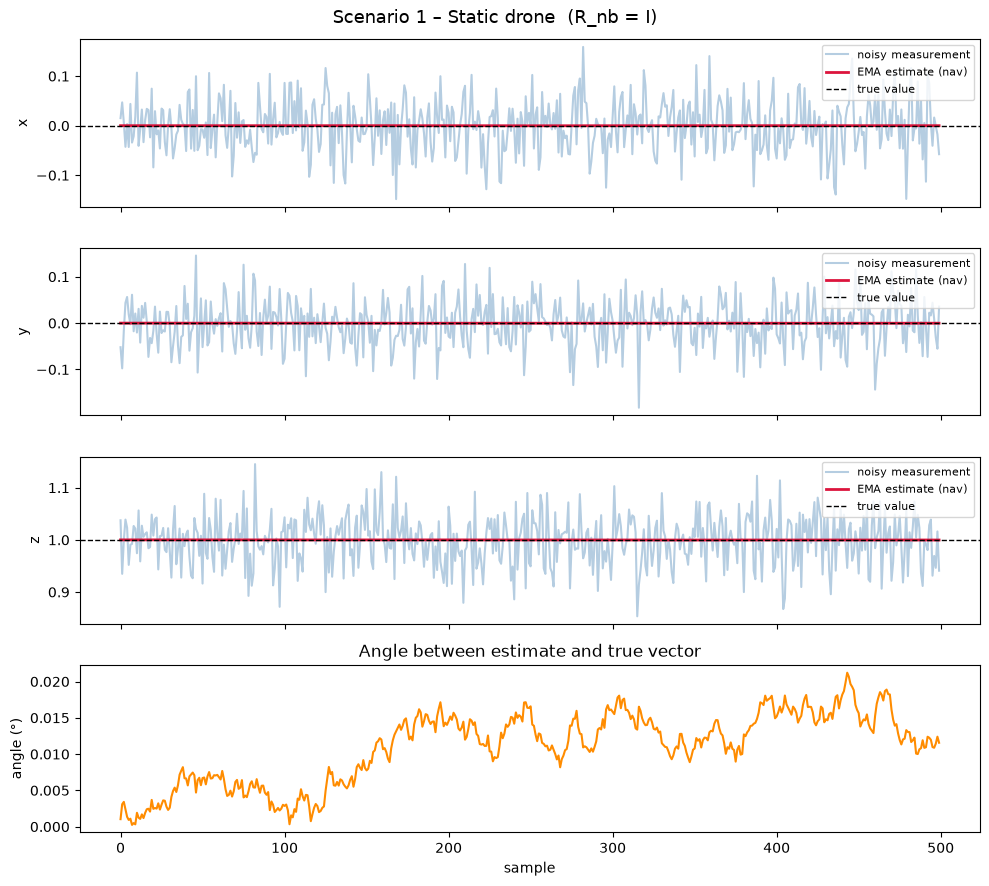

Final nav estimate : [ 2.07428079e-05 -2.00706698e-04  9.99717522e-01]
Error vs truth     : 0.000347
Final angle error  : 0.0116°


In [3]:
rng = np.random.default_rng(42)

N = 500
dt = 0.01          # 100 Hz
noise_std = 0.05

TRUE_GRAVITY_NAV = np.array([0.0, 0.0, 1.0])   # unit gravity in nav frame

alpha = 0.05       # ~39-sample window  (2 / (N+1))
f = EMAFilter.from_window_seconds(60, dt, TRUE_GRAVITY_NAV.copy())
#f = EMAFilter(alpha=alpha, initial_value=TRUE_GRAVITY_NAV.copy())

R_nb = np.eye(3)   # identity – body == nav

estimates = []
measurements = []

for _ in range(N):
    meas = TRUE_GRAVITY_NAV + rng.normal(0, noise_std, 3)
    est_body = f.update(meas, R_nb)
    measurements.append(meas.copy())
    estimates.append(f.estimate_nav.copy())   # nav-frame estimate for comparison

measurements = np.array(measurements)
estimates    = np.array(estimates)

# angle between estimate and true vector at each step
cos_theta = np.clip(
    (estimates @ TRUE_GRAVITY_NAV) /
    (np.linalg.norm(estimates, axis=1) * np.linalg.norm(TRUE_GRAVITY_NAV)),
    -1.0, 1.0,
)
angle_deg = np.degrees(np.arccos(cos_theta))

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
labels = ['x', 'y', 'z']
for i, (ax, lbl) in enumerate(zip(axes[:3], labels)):
    ax.plot(measurements[:, i], alpha=0.4, label='noisy measurement', color='steelblue')
    ax.plot(estimates[:, i],    label='EMA estimate (nav)', color='crimson', linewidth=2)
    ax.axhline(TRUE_GRAVITY_NAV[i], color='k', linestyle='--', linewidth=1, label='true value')
    ax.set_ylabel(lbl)
    ax.legend(loc='upper right', fontsize=8)

axes[3].plot(angle_deg, color='darkorange', linewidth=1.5)
axes[3].set_ylabel('angle (°)')
axes[3].set_title('Angle between estimate and true vector')

axes[-1].set_xlabel('sample')
fig.suptitle('Scenario 1 – Static drone  (R_nb = I)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Final nav estimate : {estimates[-1]}')
print(f'Error vs truth     : {np.linalg.norm(estimates[-1] - TRUE_GRAVITY_NAV):.6f}')
print(f'Final angle error  : {angle_deg[-1]:.4f}°')

## Scenario 2 — Slow constant roll (body frame rotates in nav)

The drone rolls 90° over 500 steps. The nav-frame gravity stays `[0, 0, 1]` but the body-frame measurement axis changes. The filter should keep its **nav estimate stable** while the returned body-frame vector tracks the rotation.

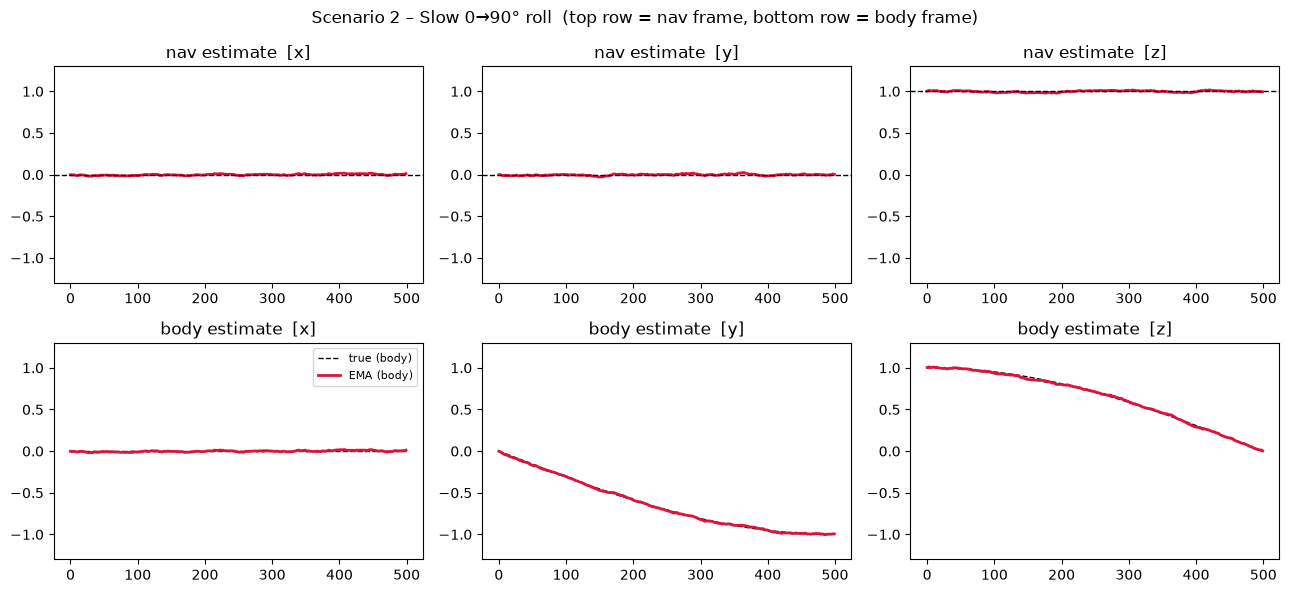

Final nav estimate : [0.01169634 0.00355093 0.99456892]
Nav error vs truth : 0.013376
Body error (last)  : 0.013376


In [4]:
N = 500
roll_angles = np.linspace(0, np.pi / 2, N)   # 0 → 90° roll

f2 = EMAFilter(alpha=alpha, initial_value=TRUE_GRAVITY_NAV.copy())


est_nav_list  = []
est_body_list = []
true_body_list = []

for roll in roll_angles:
    R_nb = Rotation.from_euler('x', roll).as_matrix()   # nav-to-body rotation
    true_body = R_nb @ TRUE_GRAVITY_NAV                  # gravity in body frame
    meas_body = true_body + rng.normal(0, noise_std, 3)

    est_body = f2.update(meas_body, R_nb)
    est_nav_list.append(f2.estimate_nav.copy())
    est_body_list.append(est_body.copy())
    true_body_list.append(true_body.copy())

est_nav   = np.array(est_nav_list)
est_body  = np.array(est_body_list)
true_body = np.array(true_body_list)

fig, axes = plt.subplots(2, 3, figsize=(13, 6))

for i, lbl in enumerate(labels):
    # Nav frame – should stay flat at [0,0,1]
    axes[0, i].plot(est_nav[:, i], color='crimson', linewidth=2)
    axes[0, i].axhline(TRUE_GRAVITY_NAV[i], color='k', linestyle='--', linewidth=1)
    axes[0, i].set_title(f'nav estimate  [{lbl}]')
    axes[0, i].set_ylim(-1.3, 1.3)

    # Body frame – should track true_body
    axes[1, i].plot(true_body[:, i], 'k--', linewidth=1, label='true (body)')
    axes[1, i].plot(est_body[:, i],  color='crimson', linewidth=2, label='EMA (body)')
    axes[1, i].set_title(f'body estimate  [{lbl}]')
    axes[1, i].set_ylim(-1.3, 1.3)
    if i == 0:
        axes[1, i].legend(fontsize=8)

fig.suptitle('Scenario 2 – Slow 0→90° roll  (top row = nav frame, bottom row = body frame)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Final nav estimate : {est_nav[-1]}')
print(f'Nav error vs truth : {np.linalg.norm(est_nav[-1] - TRUE_GRAVITY_NAV):.6f}')
print(f'Body error (last)  : {np.linalg.norm(est_body[-1] - true_body[-1]):.6f}')

## Scenario 3 — Fast step rotation (stress test)

Drone instantly jumps to 90° roll at the midpoint. The nav estimate should barely flinch; the body estimate should re-converge after the step.

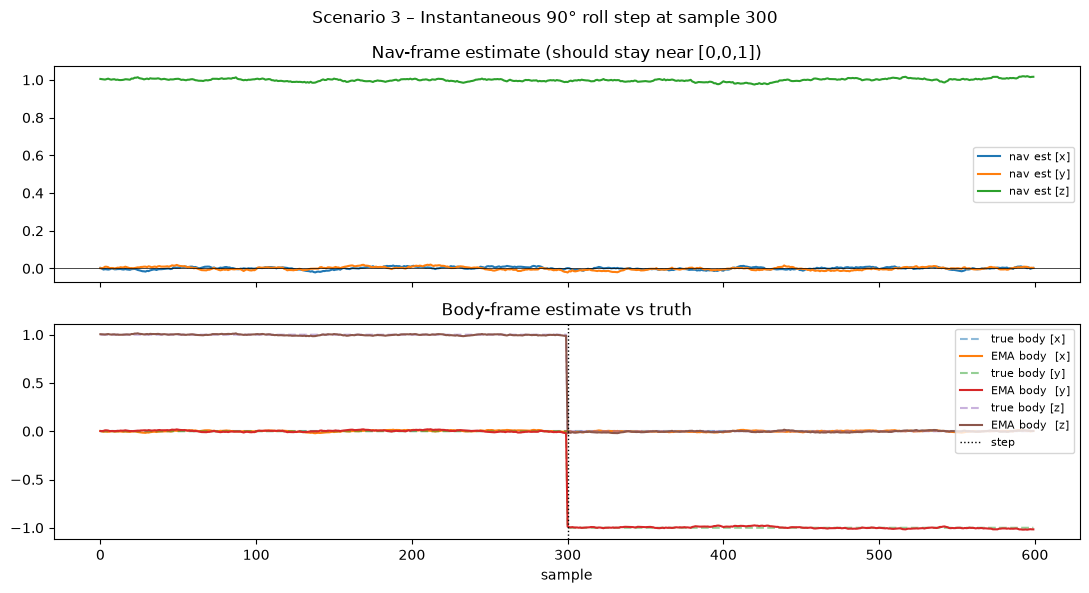

Max nav error     : 0.027165
Nav error at step : 0.024340
Nav error at end  : 0.016895


In [5]:
N = 600
f3 = EMAFilter(alpha=alpha, initial_value=TRUE_GRAVITY_NAV.copy())

est_nav_list2  = []
est_body_list2 = []
true_body_list2 = []

for k in range(N):
    roll = 0.0 if k < N // 2 else np.pi / 2   # step at halfway
    R_nb = Rotation.from_euler('x', roll).as_matrix()
    true_body = R_nb @ TRUE_GRAVITY_NAV
    meas_body = true_body + rng.normal(0, noise_std, 3)

    est_body = f3.update(meas_body, R_nb)
    est_nav_list2.append(f3.estimate_nav.copy())
    est_body_list2.append(est_body.copy())
    true_body_list2.append(true_body.copy())

est_nav2   = np.array(est_nav_list2)
est_body2  = np.array(est_body_list2)
true_body2 = np.array(true_body_list2)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for i, lbl in enumerate(labels):
    axes[0].plot(est_nav2[:, i],  label=f'nav est [{lbl}]')

for i, lbl in enumerate(labels):
    axes[1].plot(true_body2[:, i], '--', alpha=0.5, label=f'true body [{lbl}]')
    axes[1].plot(est_body2[:, i],         label=f'EMA body  [{lbl}]')

axes[0].set_title('Nav-frame estimate (should stay near [0,0,1])')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].legend(fontsize=8)
axes[1].set_title('Body-frame estimate vs truth')
axes[1].axvline(N // 2, color='k', linewidth=1, linestyle=':', label='step')
axes[1].legend(fontsize=8)
axes[-1].set_xlabel('sample')

fig.suptitle('Scenario 3 – Instantaneous 90° roll step at sample 300', fontsize=12)
plt.tight_layout()
plt.show()

# Check nav estimate drift around the step
nav_error = np.linalg.norm(est_nav2 - TRUE_GRAVITY_NAV, axis=1)
print(f'Max nav error     : {nav_error.max():.6f}')
print(f'Nav error at step : {nav_error[N//2]:.6f}')
print(f'Nav error at end  : {nav_error[-1]:.6f}')